# 07. Hyperparameter Tuning

`train_eda_revised.csv`와 `test_eda_revised.csv`로 Logistic Regression, Random Forest, XGBoost, LightGBM의 기본 성능과 Optuna 튜닝 후 성능을 비교한다. 마지막에는 튜닝된 base model로 stacking 성능까지 확인한다.

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, fbeta_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import xgboost as xgb
import lightgbm as lgb

# 경고와 Optuna 로그는 결과 표를 보기 쉽게 최소화한다.
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
N_SPLITS = 5
N_TRIALS = 50

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

DATA_DIR = Path('../data')
TRAIN_PATH = DATA_DIR / 'train_eda_revised.csv'
TEST_PATH = DATA_DIR / 'test_eda_revised.csv'

## 데이터 로드 및 전처리

타깃 누수 가능성이 있거나 식별자에 가까운 컬럼은 먼저 제거한다. 튜닝은 train 내부 cross validation으로 진행하고, 최종 평가는 test 데이터로만 본다.

In [8]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

# 시간 기반 validation을 위해 기준일 순서로 정렬한다.
for df in [train, test]:
    df['baseline_create_date'] = pd.to_datetime(df['baseline_create_date'])

train = train.sort_values('baseline_create_date').reset_index(drop=True)
test = test.sort_values('baseline_create_date').reset_index(drop=True)

# 모델이 실제 예측 시점에 알 수 없거나 식별자 성격이 강한 컬럼 제거
drop_cols = [
    'cust_number', 'name_customer', 'clear_date', 'buisness_year', 'due_in_date',
    'posting_id', 'baseline_create_date', 'target_old', 'year_month',
    'year_quarter', 'business_days_late'
]

train = train.drop(columns=[col for col in drop_cols if col in train.columns])
test = test.drop(columns=[col for col in drop_cols if col in test.columns])

# target 분리 후 나머지 컬럼만 모델 입력으로 사용
train_y = train['target'].astype(int)
test_y = test['target'].astype(int)
train_x = train.drop(columns='target')
test_x = test.drop(columns='target')

# 모델 입력에 직접 누수 컬럼이 남아있는지 확인
leakage_check_cols = {
    'clear_date', 'due_in_date', 'baseline_create_date', 'target_old',
    'business_days_late', 'delay_days', 'target', 'posting_id'
}
print('남아있는 누수 의심 컬럼:', sorted(set(train_x.columns) & leakage_check_cols))

# 수치형/범주형 컬럼을 나누어 pipeline에서 일관되게 전처리
cat_cols = train_x.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = train_x.select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f'train shape: {train_x.shape}')
print(f'test shape : {test_x.shape}')
print(f'categorical columns: {len(cat_cols)}, numeric columns: {len(num_cols)}')

남아있는 누수 의심 컬럼: []
train shape: (32000, 45)
test shape : (8000, 45)
categorical columns: 3, numeric columns: 42


In [9]:
def make_preprocessor(scale_numeric=False):
    # 선형 모델은 스케일링, 트리 계열 모델은 원래 스케일 유지
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))

    numeric_transformer = Pipeline(numeric_steps)
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    return ColumnTransformer([
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])


def make_pipeline(model, scale_numeric=False):
    return Pipeline([
        ('preprocess', make_preprocessor(scale_numeric=scale_numeric)),
        ('model', model)
    ])


# 이전 구간으로 학습하고 이후 구간으로 검증한다.
cv = TimeSeriesSplit(n_splits=N_SPLITS)

# XGBoost의 class imbalance 보정에 사용한다.
positive = train_y.sum()
negative = len(train_y) - positive
scale_pos_weight = negative / positive

print(f'scale_pos_weight: {scale_pos_weight:.3f}')

scale_pos_weight: 14.023


## 기본 모델 성능

튜닝 전 모델은 기존 modeling 노트북의 설정과 최대한 비슷하게 둔다.

In [10]:
# 튜닝 전 기준 성능을 확인할 모델들
baseline_models = {
    'Logistic Regression': make_pipeline(
        LogisticRegression(max_iter=5000, random_state=SEED, class_weight='balanced'),
        scale_numeric=True
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(n_estimators=300, random_state=SEED, class_weight='balanced', n_jobs=-1)
    ),
    'XGBoost': make_pipeline(
        xgb.XGBClassifier(n_estimators=300, random_state=SEED, eval_metric='logloss', n_jobs=-1)
    ),
    'LightGBM': make_pipeline(
        lgb.LGBMClassifier(n_estimators=300, random_state=SEED, verbose=-1, n_jobs=1)
    )
}


def evaluate_model(name, model):
    # 최종 성능 비교는 test_eda_revised 기준으로 계산
    model.fit(train_x, train_y)
    pred = model.predict(test_x)
    return {
        'model': name,
        'accuracy': accuracy_score(test_y, pred),
        'macro_f1': f1_score(test_y, pred, average='macro')
    }


# 동일한 test set에서 튜닝 전 성능을 비교한다.
baseline_results = [evaluate_model(name, model) for name, model in baseline_models.items()]
baseline_df = pd.DataFrame(baseline_results)
baseline_df

,model,accuracy,macro_f1
0,Logistic Regression,0.594000,0.458305
1,Random Forest,0.959375,0.705871
2,XGBoost,0.961500,0.761465
3,LightGBM,0.961750,0.754648


## Optuna 튜닝

`macro F1`을 objective로 사용한다. trial 수는 실행 시간을 고려해 50회로 두고, 더 오래 돌릴 수 있으면 `N_TRIALS`만 늘린다.

In [11]:
# 모델별 최적 파라미터를 이후 최종 학습에 재사용한다.
best_params = {}


def tune_model(model_name, objective):
    # TPE sampler로 각 모델의 하이퍼파라미터 공간 탐색
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    best_params[model_name] = study.best_params
    print(f'[{model_name}] best macro F1: {study.best_value:.4f}')
    print(study.best_params)
    return study

In [12]:
def objective_lr(trial):
    # Logistic Regression은 규제 강도와 penalty 중심으로 튜닝
    params = {
        'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
    }
    model = LogisticRegression(
        **params, solver='saga', max_iter=5000, random_state=SEED, n_jobs=-1
    )
    # 각 trial은 동일한 전처리 pipeline과 CV 기준으로 평가한다.
    pipe = make_pipeline(model, scale_numeric=True)
    scores = cross_val_score(pipe, train_x, train_y, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()


study_lr = tune_model('Logistic Regression', objective_lr)

  0%|          | 0/50 [00:00<?, ?it/s]

[Logistic Regression] best macro F1: 0.7679
{'C': 0.08769330748620895, 'penalty': 'l1', 'class_weight': None}


In [13]:
def objective_rf(trial):
    # Random Forest는 트리 깊이, leaf 조건, feature sampling 중심으로 튜닝
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 700, step=100),
        'max_depth': trial.suggest_categorical('max_depth', [None, 6, 8, 10, 12, 16, 20]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample'])
    }
    model = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1)
    # 각 trial은 동일한 전처리 pipeline과 CV 기준으로 평가한다.
    pipe = make_pipeline(model)
    scores = cross_val_score(pipe, train_x, train_y, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()


study_rf = tune_model('Random Forest', objective_rf)

  0%|          | 0/50 [00:00<?, ?it/s]

[Random Forest] best macro F1: 0.7861
{'n_estimators': 300, 'max_depth': None, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}


In [14]:
def objective_xgb(trial):
    # XGBoost는 learning rate, tree 복잡도, sampling, regularization 함께 탐색
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
    }
    model = xgb.XGBClassifier(
        **params, random_state=SEED, eval_metric='logloss', tree_method='hist',
        scale_pos_weight=scale_pos_weight, n_jobs=-1
    )
    # 각 trial은 동일한 전처리 pipeline과 CV 기준으로 평가한다.
    pipe = make_pipeline(model)
    scores = cross_val_score(pipe, train_x, train_y, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()


study_xgb = tune_model('XGBoost', objective_xgb)

  0%|          | 0/50 [00:00<?, ?it/s]

[XGBoost] best macro F1: 0.7785
{'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.04725623879109051, 'subsample': 0.9562839023752401, 'colsample_bytree': 0.6346535019630897, 'min_child_weight': 1, 'gamma': 0.026926586836369115, 'reg_alpha': 1.4118976666916096e-06, 'reg_lambda': 0.004708825926703128}


In [15]:
def objective_lgbm(trial):
    # LightGBM은 leaf 수와 regularization에 민감하므로 해당 범위 포함
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', -1, 16),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
    }
    model = lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1, n_jobs=1)
    # 각 trial은 동일한 전처리 pipeline과 CV 기준으로 평가한다.
    pipe = make_pipeline(model)
    scores = cross_val_score(pipe, train_x, train_y, cv=cv, scoring='f1_macro', n_jobs=1)
    return scores.mean()


study_lgbm = tune_model('LightGBM', objective_lgbm)

  0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] best macro F1: 0.7820
{'n_estimators': 700, 'learning_rate': 0.014600085998213374, 'num_leaves': 50, 'max_depth': 5, 'min_child_samples': 33, 'subsample': 0.9977320788786701, 'colsample_bytree': 0.7102173476501354, 'reg_alpha': 0.11851719176282063, 'reg_lambda': 0.0098098833483673, 'class_weight': None}


## 튜닝 전후 성능 비교

In [16]:
# Optuna가 찾은 파라미터로 최종 비교 모델을 다시 만든다.
tuned_models = {
    'Logistic Regression': make_pipeline(
        LogisticRegression(
            **best_params['Logistic Regression'], solver='saga', max_iter=5000,
            random_state=SEED, n_jobs=-1
        ),
        scale_numeric=True
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(**best_params['Random Forest'], random_state=SEED, n_jobs=-1)
    ),
    'XGBoost': make_pipeline(
        xgb.XGBClassifier(
            **best_params['XGBoost'], random_state=SEED, eval_metric='logloss',
            tree_method='hist', scale_pos_weight=scale_pos_weight, n_jobs=-1
        )
    ),
    'LightGBM': make_pipeline(
        lgb.LGBMClassifier(**best_params['LightGBM'], random_state=SEED, verbose=-1, n_jobs=1)
    )
}

tuned_results = [evaluate_model(name, model) for name, model in tuned_models.items()]
tuned_df = pd.DataFrame(tuned_results)

# 튜닝 전후 test 성능을 한 표로 묶는다.
comparison_df = pd.concat([
    baseline_df.assign(setting='Before tuning'),
    tuned_df.assign(setting='After tuning')
], ignore_index=True)

comparison_df[['setting', 'model', 'accuracy', 'macro_f1']].sort_values(['model', 'setting'])

,setting,model,accuracy,macro_f1
7,After tuning,LightGBM,0.964000,0.764921
3,Before tuning,LightGBM,0.961750,0.754648
4,After tuning,Logistic Regression,0.959375,0.739029
0,Before tuning,Logistic Regression,0.594000,0.458305
5,After tuning,Random Forest,0.959250,0.764810
1,Before tuning,Random Forest,0.959375,0.705871
6,After tuning,XGBoost,0.959500,0.752581
2,Before tuning,XGBoost,0.961500,0.761465


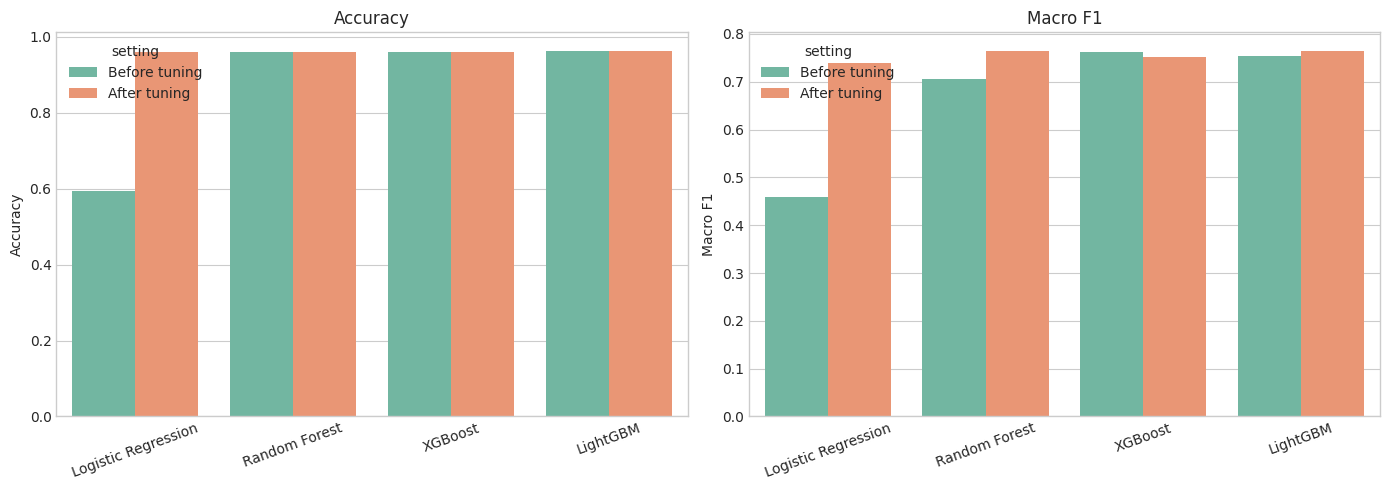

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=comparison_df, x='model', y='accuracy', hue='setting', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_xlabel('')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=comparison_df, x='model', y='macro_f1', hue='setting', ax=axes[1])
axes[1].set_title('Macro F1')
axes[1].set_xlabel('')
axes[1].set_ylabel('Macro F1')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Stacking 모델

각 base model의 out-of-fold 예측 확률을 meta feature로 만들고, meta model은 Logistic Regression을 사용한다.

In [42]:
def stacking_predict(base_model_dict):
    # base model의 OOF 확률을 meta model 입력으로 사용한다.
    # test 예측은 fold별 예측 확률 평균으로 사용
    oof_preds = np.zeros((len(train_x), len(base_model_dict)))
    oof_mask = np.zeros(len(train_x), dtype=bool)
    test_preds = np.zeros((len(test_x), len(base_model_dict)))

    for model_idx, (model_name, model) in enumerate(base_model_dict.items()):
        fold_test_preds = np.zeros((len(test_x), N_SPLITS))
        print(f'[{model_name}]')

        for fold, (tr_idx, val_idx) in enumerate(cv.split(train_x, train_y), start=1):
            fold_model = clone(model)
            fold_model.fit(train_x.iloc[tr_idx], train_y.iloc[tr_idx])

            oof_preds[val_idx, model_idx] = fold_model.predict_proba(train_x.iloc[val_idx])[:, 1]
            # TimeSeriesSplit에서 검증에 쓰인 행만 meta 학습에 포함한다.
            oof_mask[val_idx] = True
            fold_test_preds[:, fold - 1] = fold_model.predict_proba(test_x)[:, 1]

        test_preds[:, model_idx] = fold_test_preds.mean(axis=1)

    meta_model = LogisticRegression(
        penalty='l1', solver='saga', C=1.0, max_iter=3000, random_state=SEED
    )
    meta_model.fit(oof_preds[oof_mask], train_y.iloc[oof_mask])

    oof_meta_prob = meta_model.predict_proba(oof_preds[oof_mask])[:, 1]
    final_prob = meta_model.predict_proba(test_preds)[:, 1]
    final_pred = (final_prob >= 0.5).astype(int)

    return final_pred, final_prob, meta_model, oof_meta_prob, oof_mask


baseline_stack_pred, baseline_stack_prob, baseline_meta, baseline_oof_prob, baseline_oof_mask = stacking_predict(baseline_models)
tuned_stack_pred, tuned_stack_prob, tuned_meta, tuned_oof_prob, tuned_oof_mask = stacking_predict(tuned_models)


[Logistic Regression]
[Random Forest]
[XGBoost]
[LightGBM]
[Logistic Regression]
[Random Forest]
[XGBoost]
[LightGBM]


In [49]:
# 단일 모델과 별도로 stacking 성능을 확인한다.
stacking_df = pd.DataFrame([
    {
        'model': 'Stacking - Before tuning',
        'accuracy': accuracy_score(test_y, baseline_stack_pred),
        'macro_f1': f1_score(test_y, baseline_stack_pred, average='macro')
    },
    {
        'model': 'Stacking - After tuning',
        'accuracy': accuracy_score(test_y, tuned_stack_pred),
        'macro_f1': f1_score(test_y, tuned_stack_pred, average='macro')
    }
])

final_compare_df = pd.concat([
    comparison_df[['model', 'accuracy', 'macro_f1']].assign(group=comparison_df['setting']),
    stacking_df.assign(group='Stacking')
], ignore_index=True)

stacking_df

,model,accuracy,macro_f1
0,Stacking - Before tuning,0.96200,0.761173
1,Stacking - After tuning,0.96225,0.768085


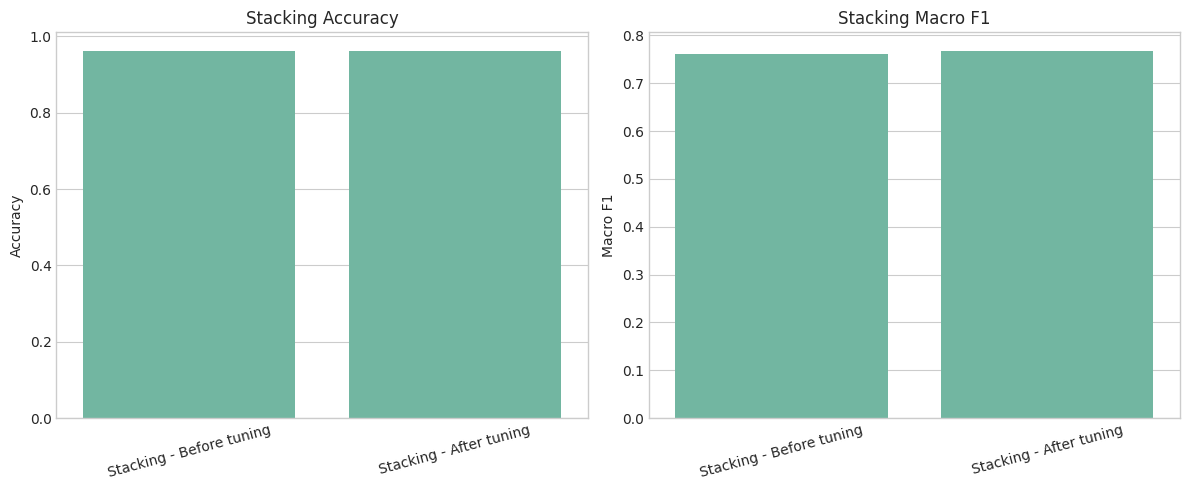

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=stacking_df, x='model', y='accuracy', ax=axes[0])
axes[0].set_title('Stacking Accuracy')
axes[0].set_xlabel('')
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=stacking_df, x='model', y='macro_f1', ax=axes[1])
axes[1].set_title('Stacking Macro F1')
axes[1].set_xlabel('')
axes[1].set_ylabel('Macro F1')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Threshold tuning

Stacking meta model의 OOF 예측 확률로 threshold를 고르고, test set에서는 고정된 threshold만 적용한다. `macro_f1`, `class1_f1`, `class1_f2` 기준을 함께 비교한다.


In [51]:
from sklearn.metrics import fbeta_score


def score_threshold(y_true, pred):
    return {
        'accuracy': accuracy_score(y_true, pred),
        'macro_f1': f1_score(y_true, pred, average='macro'),
        'class1_precision': precision_score(y_true, pred, zero_division=0),
        'class1_recall': recall_score(y_true, pred, zero_division=0),
        'class1_f1': f1_score(y_true, pred, zero_division=0),
        'class1_f2': fbeta_score(y_true, pred, beta=2, zero_division=0),
    }


def find_best_thresholds(y_true, prob):
    rows = []
    for threshold in np.arange(0.05, 0.95, 0.01):
        pred = (prob >= threshold).astype(int)
        rows.append({'threshold': threshold, **score_threshold(y_true, pred)})

    result = pd.DataFrame(rows)
    best_thresholds = {
        metric: float(result.loc[result[metric].idxmax(), 'threshold'])
        for metric in ['macro_f1', 'class1_f1', 'class1_f2']
    }
    return best_thresholds, result


threshold_target = train_y.iloc[tuned_oof_mask]
best_thresholds, threshold_df = find_best_thresholds(threshold_target, tuned_oof_prob)

threshold_configs = {
    'threshold 0.50': {
        'threshold': 0.50,
        'pred': tuned_stack_pred,
    },
    'tuned by macro_f1': {
        'threshold': best_thresholds['macro_f1'],
        'pred': (tuned_stack_prob >= best_thresholds['macro_f1']).astype(int),
    },
    'tuned by class1_f1': {
        'threshold': best_thresholds['class1_f1'],
        'pred': (tuned_stack_prob >= best_thresholds['class1_f1']).astype(int),
    },
    'tuned by class1_f2': {
        'threshold': best_thresholds['class1_f2'],
        'pred': (tuned_stack_prob >= best_thresholds['class1_f2']).astype(int),
    },
}

threshold_compare_df = pd.DataFrame([
    {
        'setting': name,
        'threshold': config['threshold'],
        **score_threshold(test_y, config['pred']),
    }
    for name, config in threshold_configs.items()
])

final_threshold_setting = 'tuned by macro_f1'
final_threshold = threshold_configs[final_threshold_setting]['threshold']
tuned_stack_threshold_pred = threshold_configs[final_threshold_setting]['pred']

print('Best thresholds from OOF')
print(pd.Series(best_thresholds).to_string())
print(f'Final report setting: {final_threshold_setting} ({final_threshold:.2f})')
threshold_compare_df


Best thresholds from OOF
macro_f1     0.44
class1_f1    0.30
class1_f2    0.07
Final report setting: tuned by macro_f1 (0.44)


,setting,threshold,accuracy,macro_f1,class1_precision,class1_recall,class1_f1,class1_f2
0,threshold 0.50,0.50,0.962250,0.768085,0.765182,0.436490,0.555882,0.477514
1,tuned by macro_f1,0.44,0.961500,0.773027,0.725632,0.464203,0.566197,0.500249
2,tuned by class1_f1,0.30,0.954625,0.757447,0.598870,0.489607,0.538755,0.508150
3,tuned by class1_f2,0.07,0.930000,0.725739,0.404223,0.618938,0.489051,0.559499


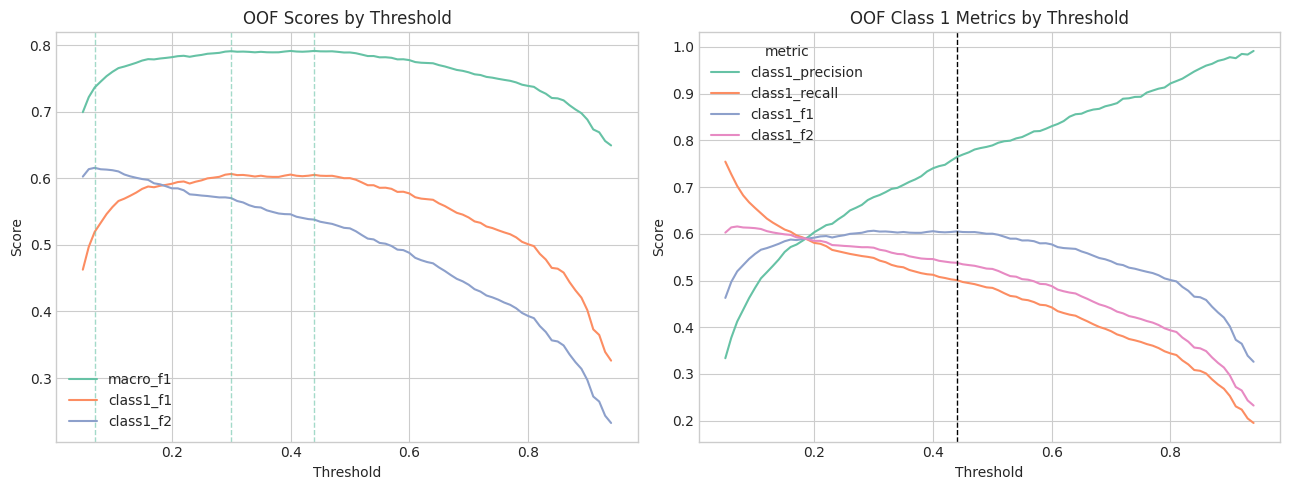

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(data=threshold_df, x='threshold', y='macro_f1', ax=axes[0], label='macro_f1')
sns.lineplot(data=threshold_df, x='threshold', y='class1_f1', ax=axes[0], label='class1_f1')
sns.lineplot(data=threshold_df, x='threshold', y='class1_f2', ax=axes[0], label='class1_f2')
for metric, threshold in best_thresholds.items():
    axes[0].axvline(threshold, linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_title('OOF Scores by Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')

plot_df = threshold_df.melt(
    id_vars='threshold',
    value_vars=['class1_precision', 'class1_recall', 'class1_f1', 'class1_f2'],
    var_name='metric',
    value_name='score'
)
sns.lineplot(data=plot_df, x='threshold', y='score', hue='metric', ax=axes[1])
axes[1].axvline(final_threshold, color='black', linestyle='--', linewidth=1)
axes[1].set_title('OOF Class 1 Metrics by Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()


[threshold 0.50 | threshold=0.50]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7567
           1       0.77      0.44      0.56       433

    accuracy                           0.96      8000
   macro avg       0.87      0.71      0.77      8000
weighted avg       0.96      0.96      0.96      8000

[tuned by macro_f1 | threshold=0.44]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7567
           1       0.73      0.46      0.57       433

    accuracy                           0.96      8000
   macro avg       0.85      0.73      0.77      8000
weighted avg       0.96      0.96      0.96      8000

[tuned by class1_f1 | threshold=0.30]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      7567
           1       0.60      0.49      0.54       433

    accuracy                           0.95      8000
   macro avg       

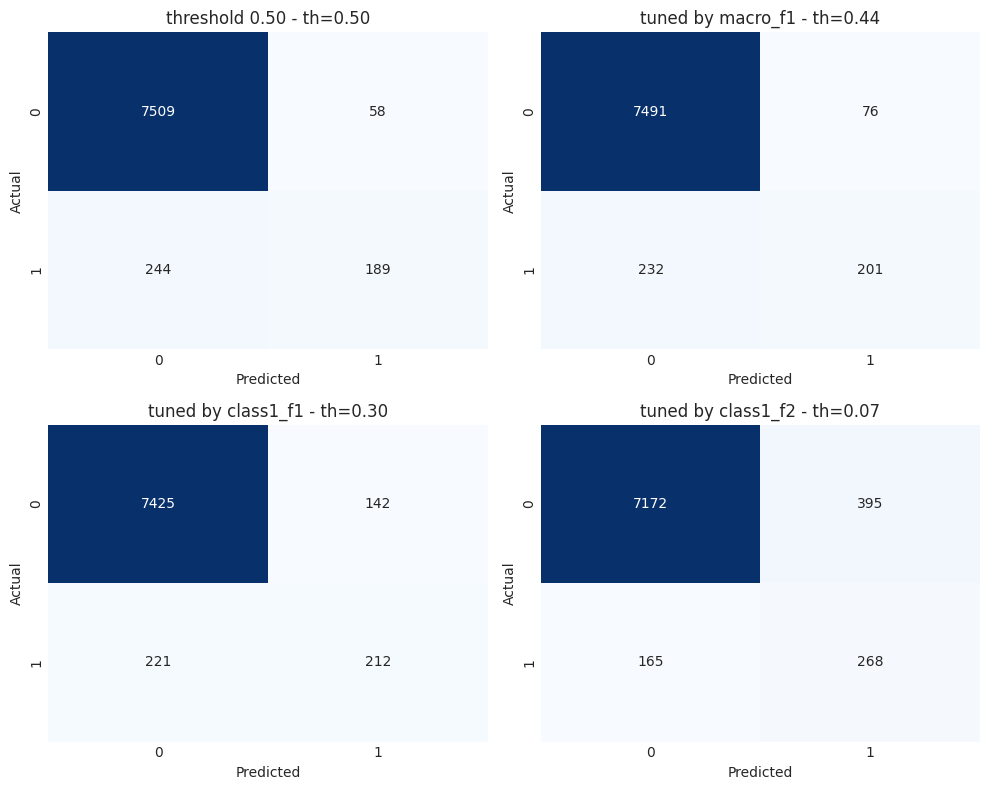

In [53]:
for name, config in threshold_configs.items():
    print(f'[{name} | threshold={config["threshold"]:.2f}]')
    print(classification_report(test_y, config['pred']))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, config) in zip(axes, threshold_configs.items()):
    cm = confusion_matrix(test_y, config['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'{name} - th={config["threshold"]:.2f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


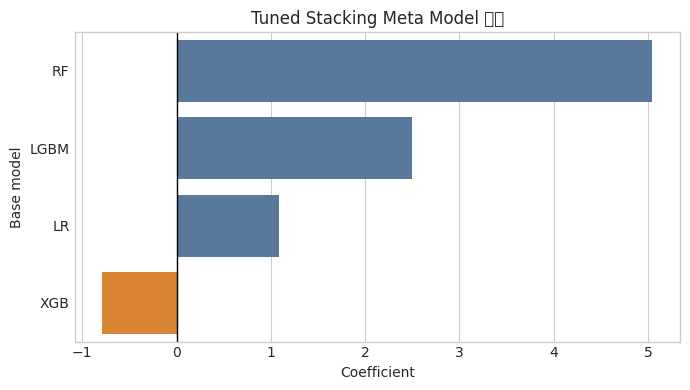

RF      5.049126
LGBM    2.501238
LR      1.090498
XGB    -0.789670
dtype: float64

In [54]:
# meta model이 어떤 base model 확률을 주로 쓰는지 확인한다.
meta_feature_names = ['LR', 'RF', 'XGB', 'LGBM']
meta_importance = pd.Series(tuned_meta.coef_[0], index=meta_feature_names).sort_values(key=abs, ascending=False)

plt.figure(figsize=(7, 4))
colors = ['#4C78A8' if value >= 0 else '#F58518' for value in meta_importance]
sns.barplot(x=meta_importance.values, y=meta_importance.index, palette=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Tuned Stacking Meta Model 계수')
plt.xlabel('Coefficient')
plt.ylabel('Base model')
plt.tight_layout()
plt.show()

meta_importance